# SpotEdit on FLUX.2-klein

The GPU-runnable FLUX.2 backbone. (The heavier FLUX.2-dev backbone lives on the `backbone/flux2-dev` branch.)

> **Requires `diffusers >= 0.37`.** FLUX.2-klein (`Flux2KleinPipeline` / `pipeline_flux2_klein`) is not available in `diffusers <= 0.36` — `import` will fail with `ModuleNotFoundError: pipeline_flux2_klein`. Upgrade with `pip install -U diffusers` if needed.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from diffusers import Flux2KleinPipeline
from diffusers.utils import load_image
from FLUX2.flux2klein_spotedit import generate   # klein-specific SpotEdit generate
from FLUX2.flux2_spot_ultis import SpotEditConfig

In [3]:
pipe = Flux2KleinPipeline.from_pretrained('black-forest-labs/FLUX.2-klein-4B', torch_dtype=torch.bfloat16).to('cuda')

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
image = load_image('./asset/dog.jpg')
image = image.resize((1024, 1024))

In [5]:
config = SpotEditConfig(threshold=0.2)

## SpotEdit (accelerated)
Pass `aux={}` to also capture the reuse mask for the visualisation below.

Guidance scale 4.0 is ignored for step-wise distilled models.


  0%|          | 0/50 [00:00<?, ?it/s]

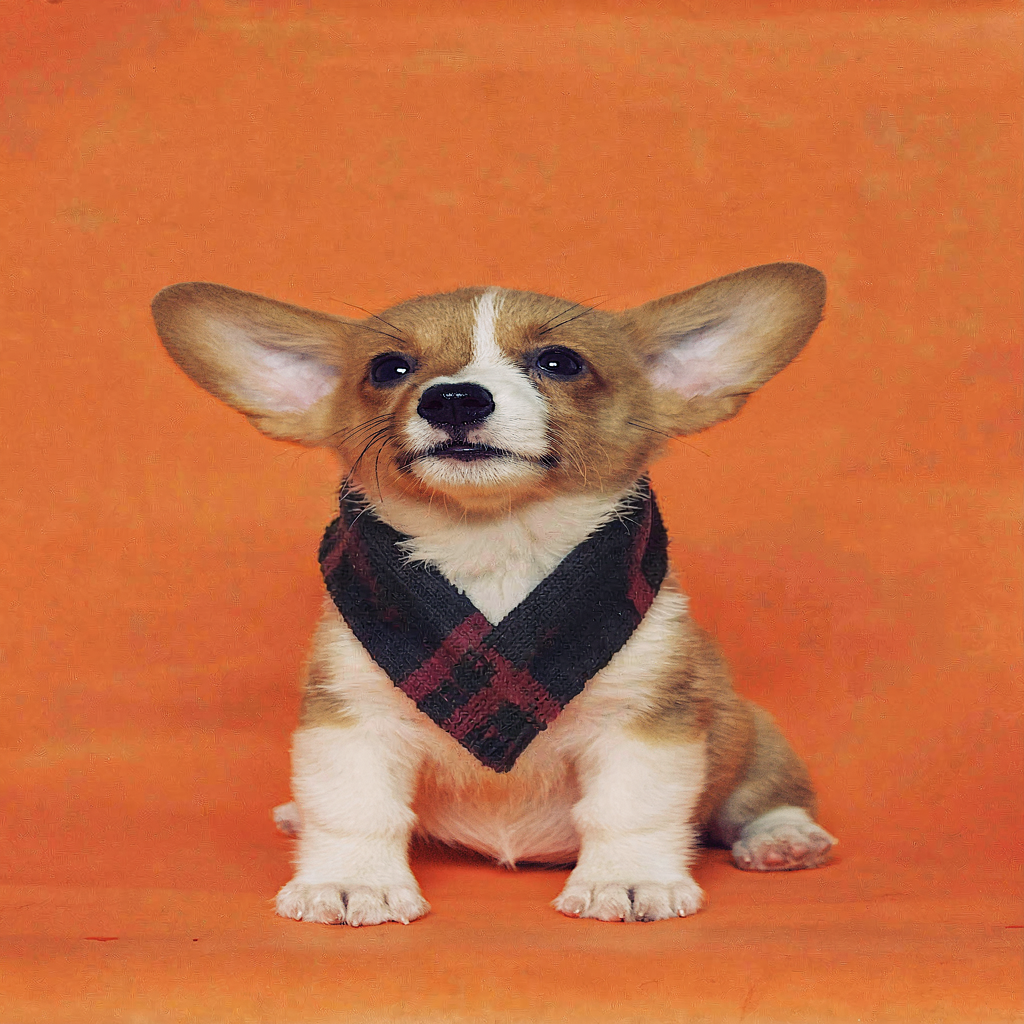

In [6]:
aux = {}
res = generate(
    pipe,
    image = image,
    prompt = 'add a scarf to the dog',
    config = config,
    aux = aux,
    num_inference_steps=50,
    guidance_scale=4.0,
)
res.images[0]

## No SpotEdit (baseline)
The same `generate()` with caching disabled (`initial_steps` > steps → full compute every step) — a fair same-code-path reference. SpotEdit should match this closely.

Guidance scale 4.0 is ignored for step-wise distilled models.


  0%|          | 0/50 [00:00<?, ?it/s]

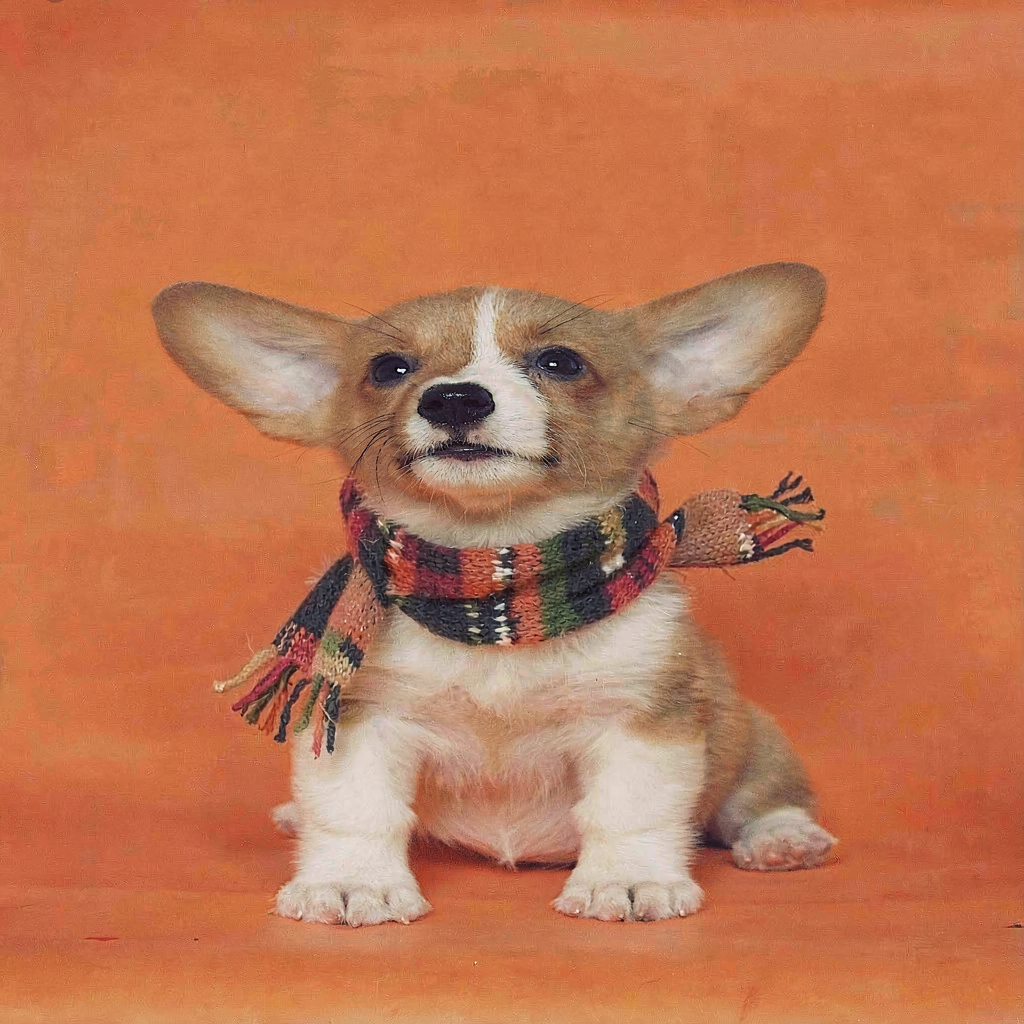

In [7]:
base = generate(
    pipe,
    image = image,
    prompt = 'add a scarf to the dog',
    config = SpotEditConfig(initial_steps=51),   # > num_inference_steps -> no reuse
    num_inference_steps=50,
    guidance_scale=4.0,
)
base.images[0]

## Reuse region
The cached (non-edited) tokens SpotEdit skipped are tinted; full-colour = the recomputed (edited) region. The reuse decision is made against the first reference image.

reused 13% of tokens (tinted region)


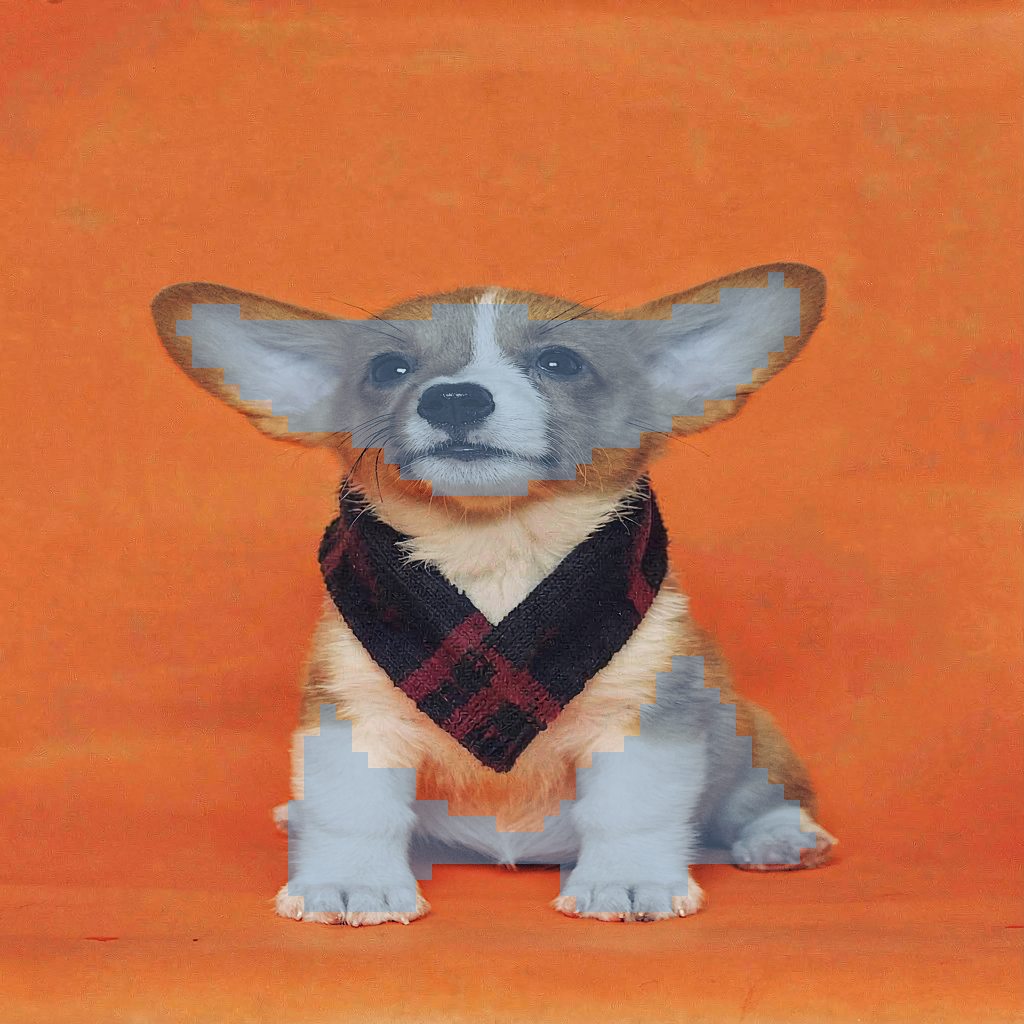

In [8]:
import numpy as np
from PIL import Image

def show_reuse(result_img, aux):
    """Tint the cached (reused, non-edited) tokens; full-colour = recomputed (edited) region."""
    m = aux['reuse_mask'].numpy().reshape(aux['H_lat'], aux['W_lat'])
    img = np.asarray(result_img.convert('RGB')).astype(np.float32)
    H, W, _ = img.shape
    up = np.asarray(Image.fromarray((m * 255).astype('uint8')).resize((W, H), Image.NEAREST)).astype(np.float32) / 255.0
    up = up[..., None]
    gray = img.mean(2, keepdims=True)
    tint = (0.45 * img + 0.55 * gray) * 0.6 + np.array([120, 165, 205], np.float32) * 0.4
    return Image.fromarray((img * (1 - up) + tint * up).clip(0, 255).astype('uint8'))

print(f"reused {float(aux['reuse_mask'].float().mean()) * 100:.0f}% of tokens (tinted region)")
show_reuse(res.images[0], aux)

FLUX.2 has two block types (double-stream + single-stream parallel); SpotEdit caches the keys/values of both. Use square 1024x1024 inputs for best results.